# Project 3C — Signal to Noise Ratio (SNR) Calculator and Visualiser

## What this project does
Demonstrates how SNR affects signal quality, calculates SNR in dB,
and shows the relationship between noise power and signal recovery.

## Key concept
SNR = Signal Power / Noise Power (in linear scale)
SNR_dB = 10 * log10(SNR)
SNR is the single most important quality metric in any RF system.
Higher SNR = cleaner signal = more reliable communication.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp


In [31]:
def calculate_snr(clean_signal, noisy_signal):
    noise = noisy_signal - clean_signal
    signal_power = np.mean(clean_signal ** 2)
    noise_power = np.mean(noise ** 2)
    snr_linear = signal_power/noise_power
    snr_db = 10 * np.log10(snr_linear)
    return snr_linear, snr_db

print("SNR calculator function defined")
print("Formula: SNR_dB = 10 * log10(signal_power / noise_power)")
    

SNR calculator function defined
Formula: SNR_dB = 10 * log10(signal_power / noise_power)


In [39]:
fs = 1000
t = np.arange(0, 1, 1/fs)

f = 100
clean = np.sin(2*np.pi*f*t)
noise_amplitudes = [0.1, 0.5, 1.0, 2.0, 5.0]

snr_values = []
noisy_signal = []
for amp in noise_amplitudes:
    noise = amp * np.random.randn(len(t))
    noisy = noise + clean
    noisy_signal.append(noisy)
    snr_lin, snr_db = calculate_snr(clean, noisy)
    snr_values.append(snr_db)
    print(f"Noise amplitude: {amp:.1f} → SNR: {snr_db:.1f} dB")    

Noise amplitude: 0.1 → SNR: 17.0 dB
Noise amplitude: 0.5 → SNR: 3.2 dB
Noise amplitude: 1.0 → SNR: -3.1 dB
Noise amplitude: 2.0 → SNR: -8.9 dB
Noise amplitude: 5.0 → SNR: -17.5 dB


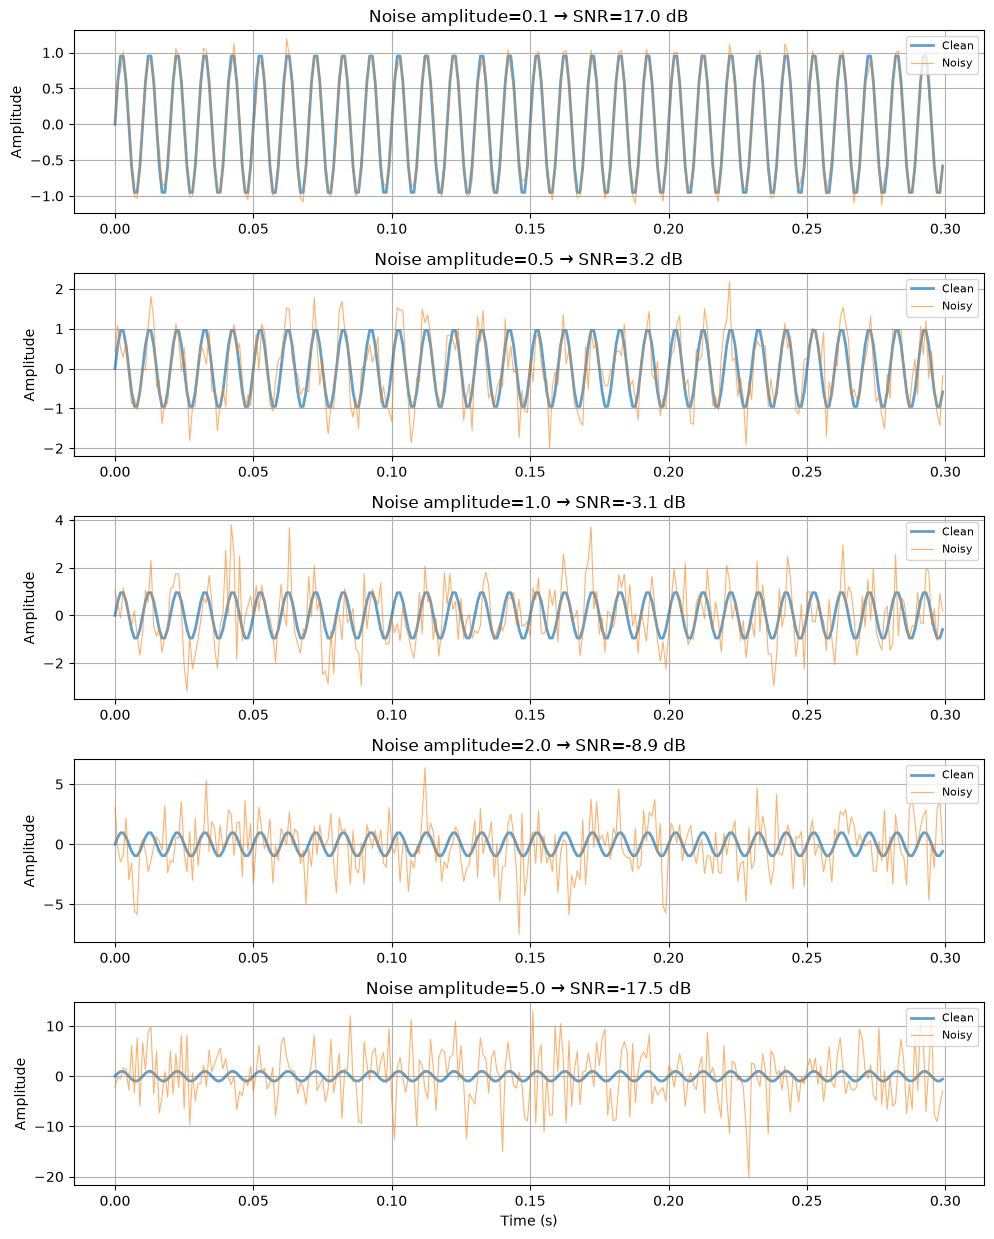

In [40]:
fig, axes = plt.subplots(len(noise_amplitudes), 1, figsize=(10, 2.5 * len(noise_amplitudes)))
for i, (noisy, amp, snr_db) in enumerate(zip(noisy_signal, noise_amplitudes, snr_values)):
    axes[i].plot(t[:300], clean[:300], label="Clean", linewidth=2, alpha=0.7)
    axes[i].plot(t[:300], noisy[:300], label="Noisy", alpha=0.6, linewidth=0.8)
    axes[i].set_title(f"Noise amplitude={amp} → SNR={snr_db:.1f} dB")
    axes[i].set_ylabel("Amplitude")
    axes[i].legend(loc="upper right", fontsize=8)
    axes[i].grid(True)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()